In [16]:
import spacy
import pandas as pd

nlp = spacy.load('en_core_web_lg')
df = pd.read_json('news_dataset.json')

df.shape

(7500, 2)

In [17]:
df.head(10)

,text,category
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS
3,This Richard Sherman Interception Literally Sh...,SPORTS
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS
5,Face to Face with SHE -- Insights from WPP Str...,BUSINESS
6,Samantha Ponder Is Living Her Dream In Sports ...,SPORTS
7,Falling Palm Tree Kills Man Going To Funeral,CRIME
8,Michael Phelps Qualifies For A Record Fifth Ol...,SPORTS
9,Bodies Recovered At Scene Of New York City Bui...,CRIME


In [18]:
df.category.value_counts()

category
CRIME       2500
SPORTS      2500
BUSINESS    2500
Name: count, dtype: int64

In [19]:
df['label_num'] = df['category'].map({"CRIME":0,"SPORTS":1,"BUSINESS":2})

In [20]:
df.head()

,text,category,label_num
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1
3,This Richard Sherman Interception Literally Sh...,SPORTS,1
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2


In [21]:
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return ' '.join(filtered_tokens)

In [22]:
df['preprocessed_text'] = df['text'].apply(preprocess)

In [23]:
df.head(5)

,text,category,label_num,preprocessed_text
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz


In [25]:
df['vector'] = df['preprocessed_text'].apply(lambda text:nlp(text).vector)

In [26]:
df.head()

,text,category,label_num,preprocessed_text,vector
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...,"[-0.3472573, 0.021758832, -0.2137525, -0.01718..."
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse,"[-0.16791849, 0.43708333, 0.035527337, 0.01661..."
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...,"[0.053351898, 0.08053064, -0.05101806, -0.1991..."
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...,"[-0.038867258, 0.28459162, 0.071352966, -0.045..."
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz,"[-0.20180944, 0.11867001, 0.0036708585, -0.189..."


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)

In [29]:
import numpy as np

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")


X_train shape (6000,)
X_test shape (1500,)


In [31]:
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

print(f"X_train shape {X_train_2d.shape}")
print(f"X_test shape {X_test_2d.shape}")

X_train shape (6000, 300)
X_test shape (1500, 300)


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

clf = DecisionTreeClassifier()

clf.fit(X_train_2d,y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       500
           1       0.75      0.73      0.74       500
           2       0.74      0.75      0.74       500

    accuracy                           0.76      1500
   macro avg       0.76      0.76      0.76      1500
weighted avg       0.76      0.76      0.76      1500



In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.fit_transform(X_test_2d)

clf = MultinomialNB()

clf.fit(scaled_train_embed,y_train)

y_pred  = clf.predict(scaled_test_embed)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       500
           1       0.98      0.61      0.75       500
           2       0.73      0.97      0.83       500

    accuracy                           0.83      1500
   macro avg       0.86      0.83      0.83      1500
weighted avg       0.86      0.83      0.83      1500



In [34]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

clf.fit(X_train_2d,y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       500
           1       0.94      0.86      0.90       500
           2       0.91      0.90      0.91       500

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



In [35]:
from sklearn.ensemble import RandomForestClassifier

clf  = RandomForestClassifier()

clf.fit(X_train_2d,y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       500
           1       0.92      0.85      0.89       500
           2       0.89      0.94      0.91       500

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



In [36]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier()

clf.fit(X_train_2d,y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       500
           1       0.94      0.89      0.91       500
           2       0.91      0.94      0.93       500

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[462,  18,  20],
       [ 30, 446,  24],
       [ 16,  13, 471]])

Text(95.72222222222221, 0.5, 'Truth')

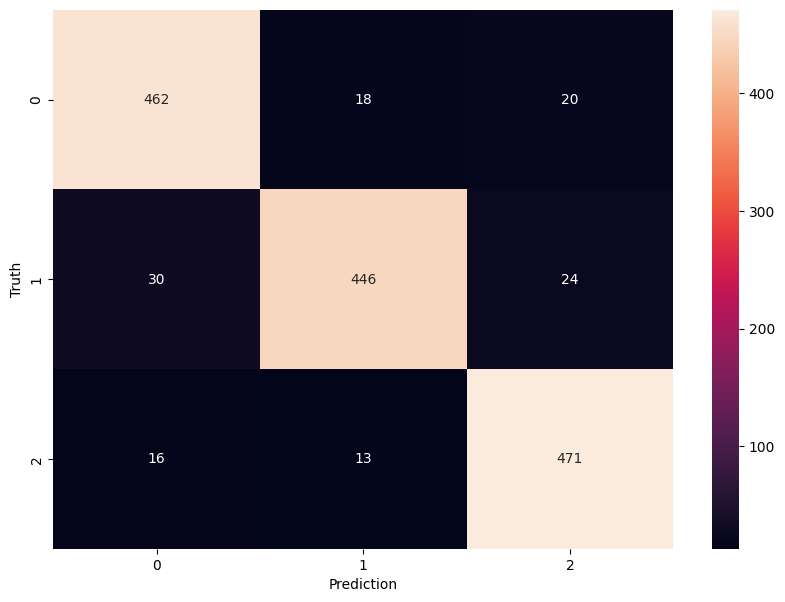

In [38]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Prediction")
plt.ylabel('Truth')